### Problem Statement - Hybrid RAG System with Automated Evaluation

### Group ID: 46
### Group members

| Name           | Email                                       | Student ID   | Contribution |
|----------------|---------------------------------------------|--------------|--------------|
|  KUPPA GOWRI SANKAR | 2024aa05936@wilp.bits-pilani.ac.in          | 2024aa05936  | 100%         |
| JAIDEEP PALIT | 2024aa05319@wilp.bits-pilani.ac.in         | 2024aa05319 |100%|
| K ROMA PAI  | 2024aa05965@wilp.bits-pilani.ac.in         | 2024aa05965 |100%|
|MANJUNATHA K N |2024ab05252@wilp.bits-pilani.ac.in   |2024ab05252|100%|
|KARTHIK REDDY S |2024ab05330@wilp.bits-pilani.ac.in|2024ab05330|100%|

### Objective

Build a Hybrid Retrieval-Augmented Generation (RAG) system combining dense vector retrieval, sparse keyword retrieval (BM25), and Reciprocal Rank Fusion (RRF) to answer questions from 500 Wikipedia articles. Evaluate using an automated framework with 100 generated questions.


### Dataset Requirements:

Wikipedia URL Collection (500 URLs per group):

Fixed Set (200 URLs): Each group must first sample a unique set of 200 Wikipedia URLs (minimum 200 words per page) covering diverse topics. Store these in a JSON file (fixed_urls.json). No two groups should share the same 200 URLs. These URLs remain constant across all indexing operations.

Random Set (300 URLs): For each indexing run, randomly sample 300 additional Wikipedia URLs (minimum 200 words per page). These should change every time the system is rebuilt/indexed.

Total Corpus: 200 fixed + 300 random = 500 URLs. Extract, clean, and chunk the text (200-400 tokens with 50-token overlap). Store with metadata (URL, title, unique chunk IDs).

#### Import Libraries

In [1]:
%pip install -q wikipedia sentence-transformers faiss-cpu rank-bm25 transformers torch nltk tqdm streamlit pandas gradio matplotlib seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import json
import random
import time
import uuid
import re
from tqdm import tqdm

import wikipedia
import nltk
from nltk.tokenize import word_tokenize

import numpy as np
import faiss

from sentence_transformers import SentenceTransformer
from rank_bm25 import BM25Okapi

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch
from collections import Counter
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

# NLTK setup
nltk.download('punkt')
nltk.download('punkt_tab')


/Users/romapai/Documents/Projects/BITS/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package punkt to /Users/romapai/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/romapai/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

#### Configuration

In [3]:
# Configuration
FIXED_URL_FILE = "fixed_urls.json"
MIN_WORDS = 200
NUM_FIXED = 200
NUM_RANDOM = 300
MAX_RETRIES = 10_000   # safety limit


#### Dataset creation

##### Fixed Set (200 URLs): Each group must first sample a unique set of 200 Wikipedia URLs (minimum 200 words per page) covering diverse topics. Store these in a JSON file (fixed_urls.json).

In [4]:
def fetch_valid_wiki_page():
    try:
        page = wikipedia.page(wikipedia.random())
        text = page.content
        if len(text.split()) >= MIN_WORDS:
            return {
                "url": page.url,
                "title": page.title,
                "text": text
            }
    except:
        pass
    return None


In [5]:
def load_or_create_fixed_urls():
    if os.path.exists(FIXED_URL_FILE):
        with open(FIXED_URL_FILE, "r") as f:
            fixed_pages = json.load(f)
        print(f"Loaded {len(fixed_pages)} fixed URLs from disk")
        return fixed_pages

    print("Fixed URLs not found. Creating fixed set...")
    fixed_pages = []
    seen_urls = set()

    attempts = 0
    while len(fixed_pages) < NUM_FIXED and attempts < MAX_RETRIES:
        page = fetch_valid_wiki_page()
        attempts += 1

        if page and page["url"] not in seen_urls:
            fixed_pages.append({
                "url": page["url"],
                "title": page["title"]
            })
            seen_urls.add(page["url"])

        if len(fixed_pages) % 25 == 0:
            print(f"Collected {len(fixed_pages)}/{NUM_FIXED} fixed URLs")

    if len(fixed_pages) < NUM_FIXED:
        raise RuntimeError("Could not collect enough fixed URLs")

    with open(FIXED_URL_FILE, "w") as f:
        json.dump(fixed_pages, f, indent=2)

    print("Fixed URLs saved to disk")
    return fixed_pages


In [6]:
fixed_pages = load_or_create_fixed_urls()
fixed_url_set = set(p["url"] for p in fixed_pages)

print(f"Final fixed URL count: {len(fixed_url_set)}")

df = pd.DataFrame(fixed_pages)
df.head(5)


Loaded 200 fixed URLs from disk
Final fixed URL count: 200


,url,title
0,https://en.wikipedia.org/wiki/Club_San_Carlos,Club San Carlos
1,https://en.wikipedia.org/wiki/2008_Australian_...,2008 Australian Open – Men's singles
2,https://en.wikipedia.org/wiki/Sapa_(slang),Sapa (slang)
3,https://en.wikipedia.org/wiki/Steve_Burdick,Steve Burdick
4,https://en.wikipedia.org/wiki/Masalanabo_Modja...,Masalanabo Modjadji VII


##### Random Set (300 URLs): For each indexing run, randomly sample 300 additional Wikipedia URLs (minimum 200 words per page).

In [7]:
def create_random_urls(exclude_urls):
    random_pages = []
    seen_urls = set(exclude_urls)

    attempts = 0
    while len(random_pages) < NUM_RANDOM and attempts < MAX_RETRIES:
        page = fetch_valid_wiki_page()
        attempts += 1

        if page and page["url"] not in seen_urls:
            random_pages.append({
                "url": page["url"],
                "title": page["title"]
            })
            seen_urls.add(page["url"])

        if len(random_pages) % 25 == 0:
            print(f"Collected {len(random_pages)}/{NUM_RANDOM} random URLs")

    if len(random_pages) < NUM_RANDOM:
        raise RuntimeError("Could not collect enough random URLs")

    return random_pages


In [8]:
random_pages = create_random_urls(fixed_url_set)

/Users/romapai/Documents/Projects/BITS/venv/lib/python3.14/site-packages/wikipedia/wikipedia.py:389: GuessedAtParserWarning: No parser was explicitly specified, so I'm using the best available HTML parser for this system ("html.parser"). This usually isn't a problem, but if you run this code on another system, or in a different virtual environment, it may use a different parser and behave differently.

The code that caused this warning is on line 389 of the file /Users/romapai/Documents/Projects/BITS/venv/lib/python3.14/site-packages/wikipedia/wikipedia.py. To get rid of this warning, pass the additional argument 'features="html.parser"' to the BeautifulSoup constructor.

  lis = BeautifulSoup(html).find_all('li')


Collected 25/300 random URLs
Collected 50/300 random URLs
Collected 50/300 random URLs
Collected 75/300 random URLs
Collected 75/300 random URLs
Collected 75/300 random URLs
Collected 100/300 random URLs
Collected 100/300 random URLs
Collected 100/300 random URLs
Collected 100/300 random URLs
Collected 125/300 random URLs
Collected 125/300 random URLs
Collected 150/300 random URLs
Collected 175/300 random URLs
Collected 200/300 random URLs
Collected 200/300 random URLs
Collected 200/300 random URLs
Collected 200/300 random URLs
Collected 225/300 random URLs
Collected 250/300 random URLs
Collected 250/300 random URLs
Collected 275/300 random URLs
Collected 275/300 random URLs
Collected 275/300 random URLs
Collected 300/300 random URLs


In [9]:
df = pd.DataFrame(random_pages)
df.head(5)

all_pages = fixed_pages + random_pages

assert len(all_pages) == 500
assert len(set(p["url"] for p in all_pages)) == 500

print("✅ Final corpus ready")
print(f"Fixed URLs : {len(fixed_pages)}")
print(f"Random URLs: {len(random_pages)}")

df = pd.DataFrame(all_pages)
df.head(5)

✅ Final corpus ready
Fixed URLs : 200
Random URLs: 300


,url,title
0,https://en.wikipedia.org/wiki/Club_San_Carlos,Club San Carlos
1,https://en.wikipedia.org/wiki/2008_Australian_...,2008 Australian Open – Men's singles
2,https://en.wikipedia.org/wiki/Sapa_(slang),Sapa (slang)
3,https://en.wikipedia.org/wiki/Steve_Burdick,Steve Burdick
4,https://en.wikipedia.org/wiki/Masalanabo_Modja...,Masalanabo Modjadji VII


### Preprocessing

####  Extract, clean, and chunk the text (200-400 tokens with 50-token overlap). Store with metadata (URL, title, unique chunk IDs).

In [10]:
# Cell 7: Text cleaner
def clean_text(text):
    text = re.sub(r'\n+', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

In [11]:
documents = []

for page_info in tqdm(all_pages):
    try:
        page = wikipedia.page(page_info["title"])
        text = clean_text(page.content)

        if len(text.split()) < MIN_WORDS:
            continue  # extra safety

        documents.append({
            "url": page.url,
            "title": page.title,
            "text": text
        })
    except:
        continue

print(f"Documents extracted: {len(documents)}")

 27%|██▋       | 135/500 [05:31<14:24,  2.37s/it]/Users/romapai/Documents/Projects/BITS/venv/lib/python3.14/site-packages/wikipedia/wikipedia.py:389: GuessedAtParserWarning: No parser was explicitly specified, so I'm using the best available HTML parser for this system ("html.parser"). This usually isn't a problem, but if you run this code on another system, or in a different virtual environment, it may use a different parser and behave differently.

The code that caused this warning is on line 389 of the file /Users/romapai/Documents/Projects/BITS/venv/lib/python3.14/site-packages/wikipedia/wikipedia.py. To get rid of this warning, pass the additional argument 'features="html.parser"' to the BeautifulSoup constructor.

  lis = BeautifulSoup(html).find_all('li')
100%|██████████| 500/500 [15:29<00:00,  1.86s/it]

Documents extracted: 494


#### Chunking function

In [12]:
def chunk_text(text, min_tokens=200, max_tokens=400, overlap=50):
    tokens = word_tokenize(text)
    chunks = []

    start = 0
    while start < len(tokens):
        end = min(start + max_tokens, len(tokens))
        chunk = tokens[start:end]
        if len(chunk) >= min_tokens:
            chunks.append(" ".join(chunk))
        start += max_tokens - overlap

    return chunks

####  Create chunks with metadata

In [13]:
chunks = []

for doc in tqdm(documents):
    doc_chunks = chunk_text(doc["text"])
    for idx, chunk in enumerate(doc_chunks):
        chunks.append({
            "chunk_id": str(uuid.uuid4()),
            "title": doc["title"],
            "url": doc["url"],
            "text": chunk,
            "chunk_index": idx
        })

print(f"Total chunks created: {len(chunks)}")

100%|██████████| 494/494 [00:00<00:00, 556.58it/s]

Total chunks created: 1571


In [14]:
df = pd.DataFrame(chunks)
df.head(5)

,chunk_id,title,url,text,chunk_index
0,fa9ba1a0-ed29-466c-9473-b30eb79a89aa,Club San Carlos,https://en.wikipedia.org/wiki/Club_San_Carlos,San Carlos Sports and Cultural Club is a Domin...,0
1,d3a3749d-4453-418b-a1dc-63eabf5ac243,2008 Australian Open – Men's singles,https://en.wikipedia.org/wiki/2008_Australian_...,Novak Djokovic defeated Jo-Wilfried Tsonga in ...,0
2,27ecafb5-6f86-40d2-89d1-5ddedd0cca1d,Sapa (slang),https://en.wikipedia.org/wiki/Sapa_(slang),Sapa ( SAH-PA ) is a Nigerian slang term that ...,0
3,1925a8a1-1473-4b77-9664-b3bf6073b2e5,Steve Burdick,https://en.wikipedia.org/wiki/Steve_Burdick,`` Steve Burdick '' is an episode of the 1990 ...,0
4,fb14f25b-4bc0-4bee-98f6-7aa87a2c73ff,Steve Burdick,https://en.wikipedia.org/wiki/Steve_Burdick,"his producer , Barbara Hudson , convinces the ...",1


#### Exploratory Data Analysis

In [15]:
# 1. Count how many times each URL appears
url_counts = Counter(chunk["url"] for chunk in chunks)

# 2. Extract the counts into a list
counts = list(url_counts.values())

# 3. Calculate metrics
total_unique_urls = len(url_counts)
min_chunks = min(counts) if counts else 0
max_chunks = max(counts) if counts else 0
avg_chunks = sum(counts) / len(counts) if counts else 0

# Print results
print(f"Min chunks per URL: {min_chunks}")
print(f"Max chunks per URL: {max_chunks}")
print(f"Avg chunks per URL: {avg_chunks:.2f}")

Min chunks per URL: 1
Max chunks per URL: 42
Avg chunks per URL: 3.18


In [16]:

sample_chuncks = random.sample(chunks, 5)

for i, chunk in enumerate(sample_chuncks, 1):
    print("=" * 80)
    print(f"Sample Document {i}")
    print(f"Chunk ID     : {chunk['chunk_id']}")
    print(f"URL          : {chunk['url']}")
    print(f"Word Count   : {len(chunk['text'].split())}")
    print("-" * 80)
    print(chunk['text'][:400])  # print only first 800 chars
    print("...")

Sample Document 1
Chunk ID     : 89014b77-8498-4039-a07c-0c812c4a3f08
URL          : https://en.wikipedia.org/wiki/Wat%27s_Pig
Word Count   : 229
--------------------------------------------------------------------------------
an astonishing amount of humor and pathos into its 11 minutes as it re- creates a Dark Ages setting of fan tasy and grim reality . It 's a stunning little film '' . DVD Review describes Wat 's Pig as `` Scripted , widescreen , more ordinary , and better ( than War Story ) '' . Dr. Grob gave the film two stars out of five , praising the `` silent comedy , with very little dialogue ( only ‘ me ? ’ a
...
Sample Document 2
Chunk ID     : dfcc2c39-e4c0-4373-a774-af7970f5199f
URL          : https://en.wikipedia.org/wiki/Sarah_Tudzin
Word Count   : 400
--------------------------------------------------------------------------------
Sarah Tudzin is an American record producer , audio engineer , and musician . She is also the founder and leader singer of the band Illumina

### Data Overview ###
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1571 entries, 0 to 1570
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   chunk_id     1571 non-null   object
 1   title        1571 non-null   object
 2   url          1571 non-null   object
 3   text         1571 non-null   object
 4   chunk_index  1571 non-null   int64 
dtypes: int64(1), object(4)
memory usage: 61.5+ KB
None

### Missing Values ###
chunk_id       0
title          0
url            0
text           0
chunk_index    0
dtype: int64


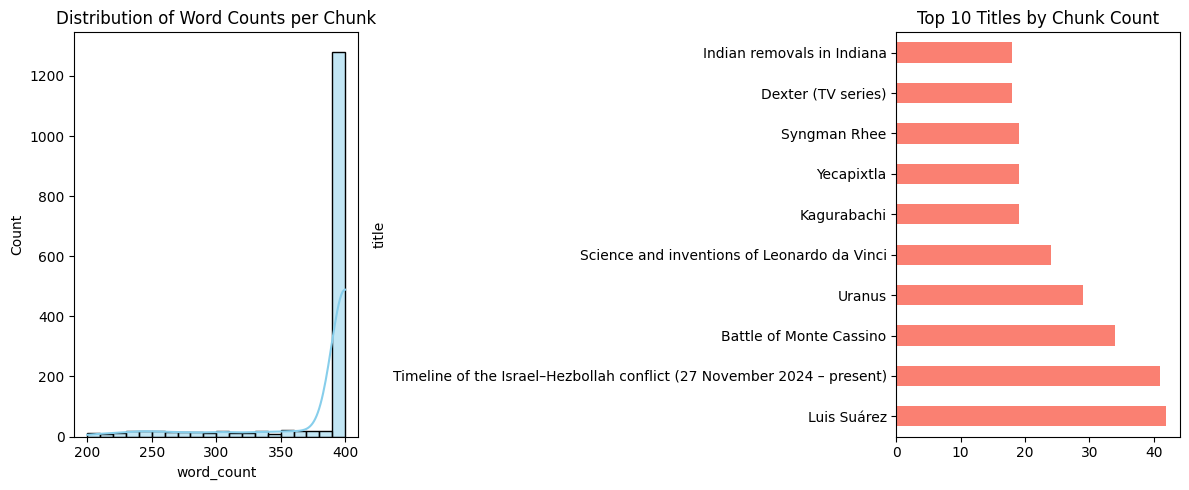


Total Chunks: 1571
Unique Titles: 494
Duplicate Chunks (by ID): 0

### Chunk Index Statistics ###
count    1571.000000
mean        4.189052
std         6.660696
min         0.000000
25%         0.000000
50%         2.000000
75%         5.000000
max        41.000000
Name: chunk_index, dtype: float64


In [17]:
# --- BASIC INSPECTION ---
print("### Data Overview ###")
print(df.info())
print("\n### Missing Values ###")
print(df.isnull().sum())

# --- TEXT SPECIFIC ANALYSIS ---
# Calculate the length of the text and word counts
df['char_count'] = df['text'].str.len()
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

# --- EDA VISUALIZATIONS ---
plt.figure(figsize=(12, 5))

# Plot 1: Distribution of word counts (Helps find outliers or empty chunks)
plt.subplot(1, 2, 1)
sns.histplot(df['word_count'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Word Counts per Chunk')

# Plot 2: Chunks per Title (Top 10 most frequent titles)
plt.subplot(1, 2, 2)
df['title'].value_counts().head(10).plot(kind='barh', color='salmon')
plt.title('Top 10 Titles by Chunk Count')

plt.tight_layout()
plt.show()

# --- DUPLICATE & REPETITION CHECK ---
print(f"\nTotal Chunks: {len(df)}")
print(f"Unique Titles: {df['title'].nunique()}")
print(f"Duplicate Chunks (by ID): {df.duplicated('chunk_id').sum()}")

# Statistics for chunk indices (checks if any pages have huge gaps or overlaps)
print("\n### Chunk Index Statistics ###")
print(df['chunk_index'].describe())

/var/folders/ym/rgp3_k3522j0ffhxxyrc6blh0000gn/T/ipykernel_55052/1492848598.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='title', y='word_count', data=df, palette='Set2')
/var/folders/ym/rgp3_k3522j0ffhxxyrc6blh0000gn/T/ipykernel_55052/1492848598.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bg_counts, y=bg_labels, palette='viridis')
/var/folders/ym/rgp3_k3522j0ffhxxyrc6blh0000gn/T/ipykernel_55052/1492848598.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='title', y='chunk_index', data=df, jitter=True, size=8, pal

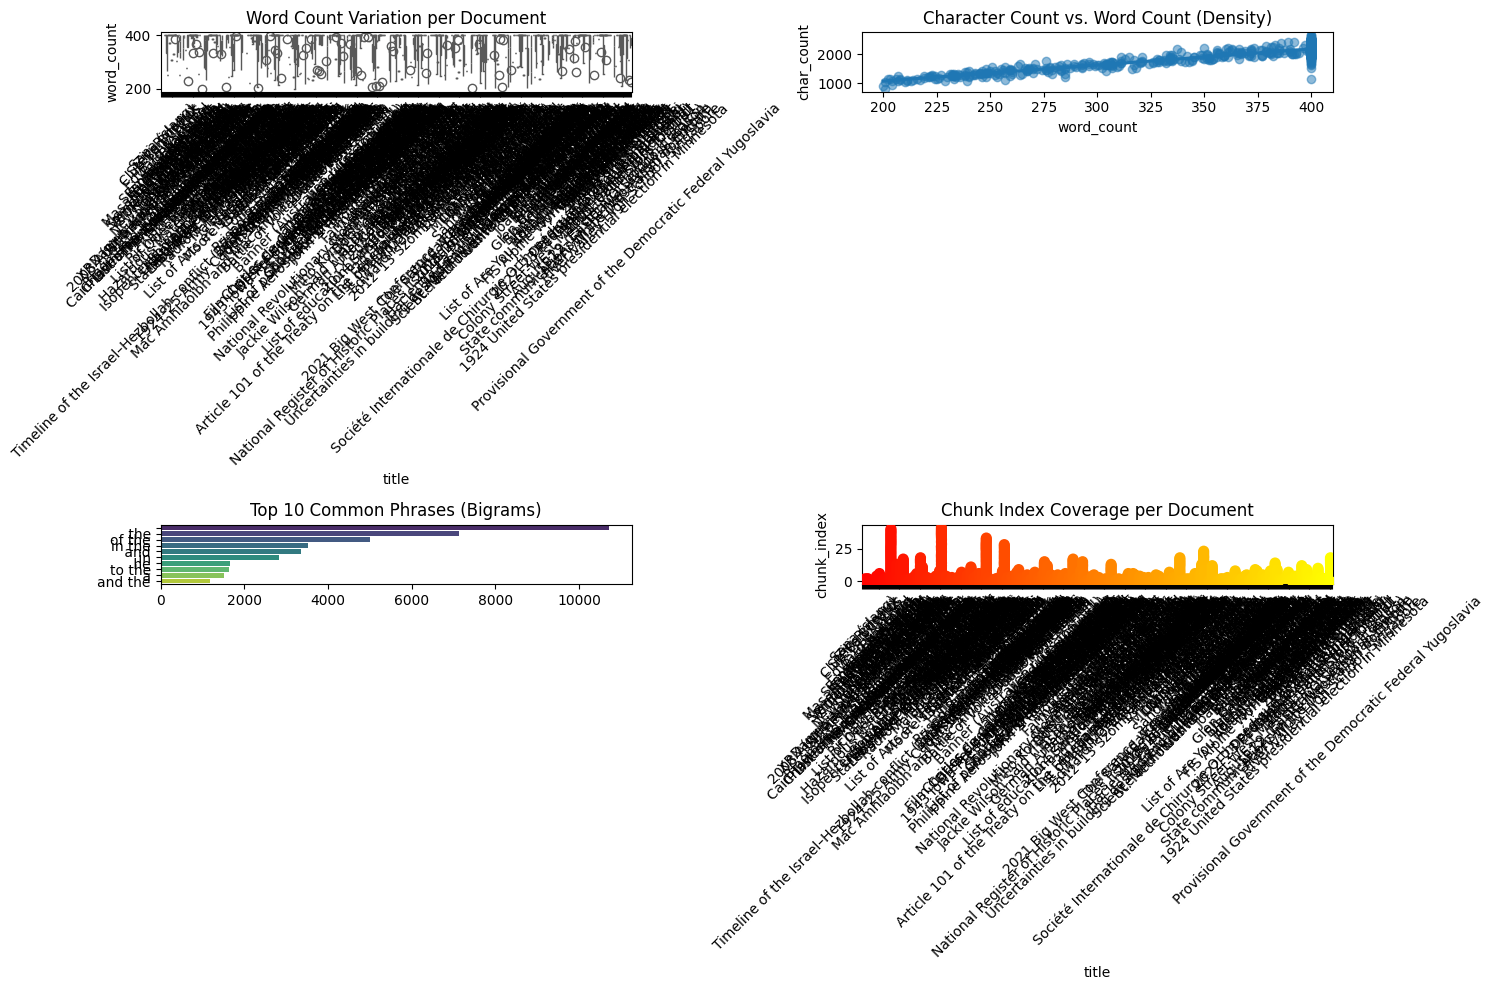

In [18]:
# Assuming 'df' is your DataFrame from the previous step
df['char_count'] = df['text'].str.len()
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

# Setup the plotting area
plt.figure(figsize=(15, 10))

# --- CHART 1: Word Count Box Plot (By Title) ---
plt.subplot(2, 2, 1)
sns.boxplot(x='title', y='word_count', data=df, palette='Set2')
plt.title('Word Count Variation per Document')
plt.xticks(rotation=45)

# --- CHART 2: Char vs Word Scatter Plot ---
plt.subplot(2, 2, 2)
sns.regplot(x='word_count', y='char_count', data=df, scatter_kws={'alpha':0.5})
plt.title('Character Count vs. Word Count (Density)')

# --- CHART 3: Top 10 Bigrams ---
plt.subplot(2, 2, 3)
def get_bigrams(text_series):
    words = " ".join(text_series).lower().split()
    words = [re.sub(r'[^\w\s]', '', w) for w in words] # Clean punctuation
    bigrams = zip(words, words[1:])
    return Counter(bigrams).most_common(10)

common_bg = get_bigrams(df['text'])
bg_labels = [f"{b[0][0]} {b[0][1]}" for b in common_bg]
bg_counts = [b[1] for b in common_bg]
sns.barplot(x=bg_counts, y=bg_labels, palette='viridis')
plt.title('Top 10 Common Phrases (Bigrams)')

# --- CHART 4: Chunk Index Coverage ---
plt.subplot(2, 2, 4)
sns.stripplot(x='title', y='chunk_index', data=df, jitter=True, size=8, palette='autumn')
plt.title('Chunk Index Coverage per Document')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Part 1: Hybrid RAG System

#### 1.1 Dense Vector Retrieval

##### Use a sentence embedding model (e.g., all-MiniLM-L6-v2) to embed chunks

In [19]:
# Load embedding model
embed_model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2476.20it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


##### Generate embeddings

In [20]:
# Generate embeddings
chunk_texts = [c["text"] for c in chunks]
embeddings = embed_model.encode(chunk_texts, show_progress_bar=True)

Batches: 100%|██████████| 50/50 [00:12<00:00,  4.12it/s]


##### Build a vector index (FAISS)

In [21]:
# Build FAISS index
dimension = embeddings.shape[1]
index = faiss.IndexFlatIP(dimension)

faiss.normalize_L2(embeddings)
index.add(embeddings)

print("FAISS index built")

FAISS index built


##### Vector Space Visualization (PCA/t-SNE)

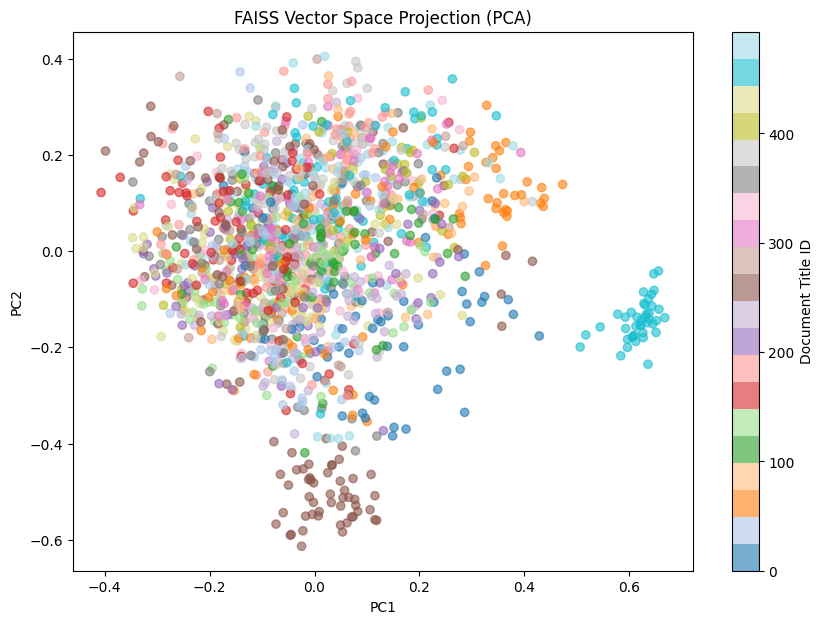

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# 1. Extract embeddings (assuming you have your 'embeddings' numpy array)
# If you only have the index, you'd need to have stored the vectors.
# Let's assume 'embeddings' is your (N, dimensions) array.

# 2. Reduce dimensions to 2D using PCA (Fast) or t-SNE (Better clusters)
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(embeddings)

# 3. Plot
plt.figure(figsize=(10, 7))
scatter = plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1],
                      c=df['title'].astype('category').cat.codes,
                      cmap='tab20', alpha=0.6)

plt.colorbar(scatter, label='Document Title ID')
plt.title('FAISS Vector Space Projection (PCA)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

##### Distance Distribution Histogram

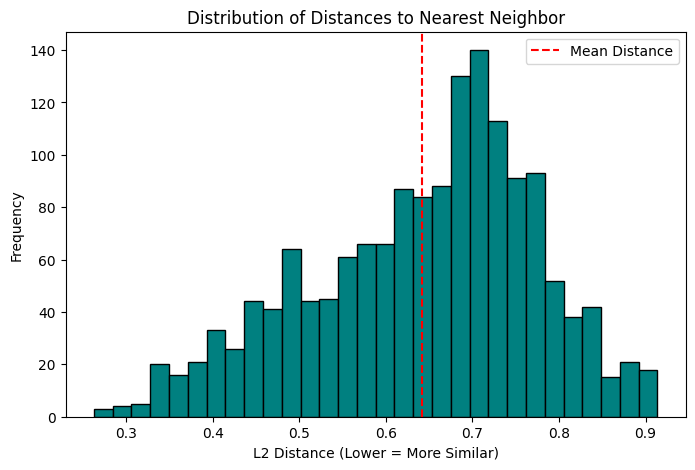

In [23]:
# 1. Search the index against itself (find nearest neighbors for each chunk)
# k=2 because the 1st result will be the chunk itself (distance 0)
D, I = index.search(embeddings, k=2)

# 2. Get the distances to the 2nd nearest neighbor (the closest 'other' chunk)
neighbor_distances = D[:, 1]

# 3. Plot the distribution
plt.figure(figsize=(8, 5))
plt.hist(neighbor_distances, bins=30, color='teal', edgecolor='black')
plt.axvline(np.mean(neighbor_distances), color='red', linestyle='dashed', label='Mean Distance')
plt.title('Distribution of Distances to Nearest Neighbor')
plt.xlabel('L2 Distance (Lower = More Similar)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

##### Retrieve top-K chunks via cosine similarity.

In [24]:
# Dense retrieval
def dense_retrieve(query, top_k=10):
    q_emb = embed_model.encode([query])
    faiss.normalize_L2(q_emb)
    scores, indices = index.search(q_emb, top_k)

    results = []
    for rank, idx in enumerate(indices[0]):
        results.append({
            "chunk": chunks[idx],
            "score": float(scores[0][rank]),
            "rank": rank + 1
        })
    return results

In [25]:
res=dense_retrieve("Where was Ellis born?")

df = pd.DataFrame(res)

df

,chunk,score,rank
0,{'chunk_id': 'd4cb1b5d-5fa8-4e91-b648-006b06a2...,0.397031,1
1,{'chunk_id': 'ce80af1d-a621-4dbb-bea7-15ab69fe...,0.354671,2
2,{'chunk_id': 'e7c0d93d-f917-4fe8-8204-caab3afd...,0.336460,3
3,{'chunk_id': '94a523f4-3397-4c08-a89d-5d2ecde8...,0.335383,4
4,{'chunk_id': '13309e2f-0e0a-472b-b12c-1d6d12bf...,0.333109,5
5,{'chunk_id': 'ffcf85ec-3578-4a77-9b55-3b380542...,0.332341,6
6,{'chunk_id': '14c108a3-0c88-46c1-a8c4-896c2922...,0.323609,7
7,{'chunk_id': 'c85c4b21-16a7-4954-b008-43dccd72...,0.313305,8
8,{'chunk_id': 'ea7f3716-d0d6-4d3c-800e-a9188020...,0.307357,9
9,{'chunk_id': '45417b19-72c3-4f95-b150-a8158bed...,0.306251,10


#### 1.2 Sparse Keyword Retrieval

##### Implement BM25 algorithm for keyword-based retrieval.

In [26]:
# Prepare BM25 corpus
tokenized_corpus = [word_tokenize(c["text"].lower()) for c in chunks]
bm25 = BM25Okapi(tokenized_corpus)

##### BM25 Analysis Plot

/var/folders/ym/rgp3_k3522j0ffhxxyrc6blh0000gn/T/ipykernel_55052/366026306.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=idf_df.head(15), x='idf', y='word', palette='magma')


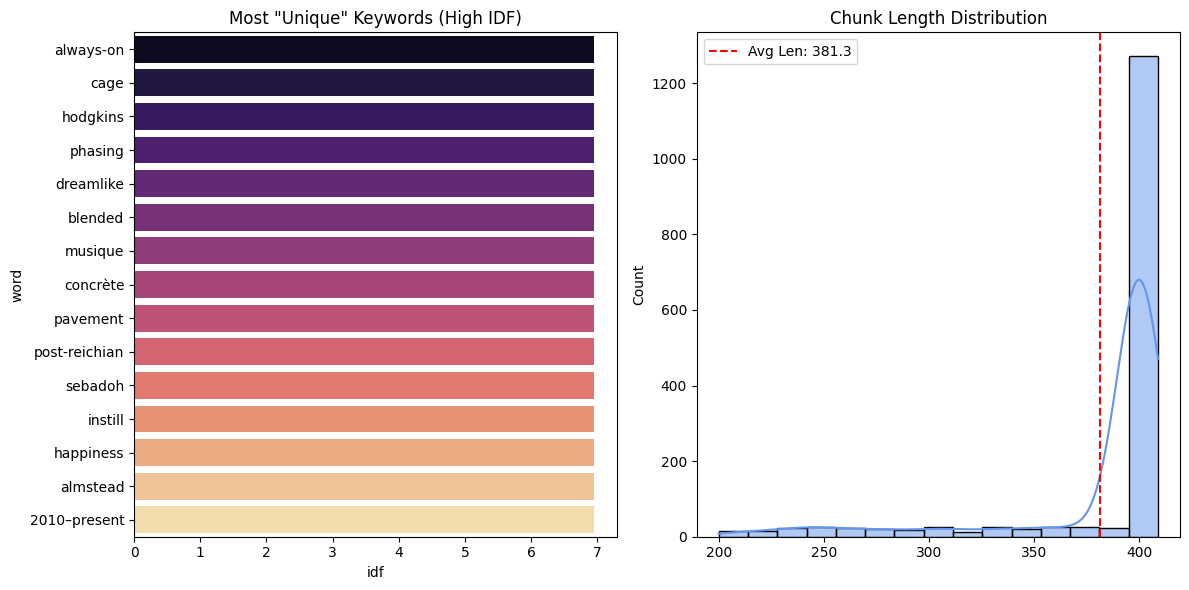

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extracting stats from the BM25 object
# bm25.doc_len is a list of lengths of all documents in the corpus
doc_lengths = bm25.doc_len
avg_dl = bm25.avgdl

# Extracting IDF data
idf_data = [{'word': word, 'idf': score} for word, score in bm25.idf.items()]
idf_df = pd.DataFrame(idf_data).sort_values(by='idf', ascending=False)

plt.figure(figsize=(12, 6))

# Chart 1: Top 15 Highest IDF Words
plt.subplot(1, 2, 1)
sns.barplot(data=idf_df.head(15), x='idf', y='word', palette='magma')
plt.title('Most "Unique" Keywords (High IDF)')

# Chart 2: Document Length Distribution
plt.subplot(1, 2, 2)
sns.histplot(doc_lengths, bins=15, kde=True, color='cornflowerblue')
plt.axvline(avg_dl, color='red', linestyle='--', label=f'Avg Len: {avg_dl:.1f}')
plt.title('Chunk Length Distribution')
plt.legend()

plt.tight_layout()
plt.show()

##### Build index over chunks and retrieve top-K results.

In [28]:
# BM25 retrieval
def bm25_retrieve(query, top_k=10):
    tokenized_query = word_tokenize(query.lower())
    scores = bm25.get_scores(tokenized_query)
    top_indices = np.argsort(scores)[::-1][:top_k]

    results = []
    for rank, idx in enumerate(top_indices):
        results.append({
            "chunk": chunks[idx],
            "score": scores[idx],
            "rank": rank + 1
        })
    return results

In [29]:
bm25_res=bm25_retrieve("Where was Ellis born?")

df = pd.DataFrame(bm25_res)

df

,chunk,score,rank
0,{'chunk_id': 'ce80af1d-a621-4dbb-bea7-15ab69fe...,9.811110,1
1,{'chunk_id': 'c29845b8-396c-471f-8cf5-a8a71840...,9.261769,2
2,{'chunk_id': 'add27af4-c276-42f2-8a9f-ab69a377...,9.135803,3
3,{'chunk_id': '0c2386e1-45e4-427a-b3de-162d0a56...,8.923904,4
4,{'chunk_id': '2ccc37d4-3064-437c-8403-be59d8a1...,8.714912,5
5,{'chunk_id': 'ea7f3716-d0d6-4d3c-800e-a9188020...,8.509168,6
6,{'chunk_id': 'ddb6bad5-a980-4916-93ed-52bd2f6a...,8.474445,7
7,{'chunk_id': 'f6210ec6-7590-4ddf-91a2-000aee54...,8.138313,8
8,{'chunk_id': '6c722d52-720b-4d13-b83e-8123d511...,8.137609,9
9,{'chunk_id': 'd64dd34c-2747-4a99-9af5-31b2d7bb...,7.994095,10


#### 1.3 Reciprocal Rank Fusion (RRF)

In [30]:
# RRF implementation
def reciprocal_rank_fusion(dense_results, sparse_results, k=60, top_n=5):
    scores = {}

    for res in dense_results:
        cid = res["chunk"]["chunk_id"]
        scores.setdefault(cid, 0)
        scores[cid] += 1 / (k + res["rank"])

    for res in sparse_results:
        cid = res["chunk"]["chunk_id"]
        scores.setdefault(cid, 0)
        scores[cid] += 1 / (k + res["rank"])

    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)

    final_chunks = []
    for cid, score in ranked[:top_n]:
        chunk = next(c for c in chunks if c["chunk_id"] == cid)
        final_chunks.append({
            "chunk": chunk,
            "rrf_score": score
        })

    return final_chunks


In [31]:
rrf_res=reciprocal_rank_fusion(dense_results=res,sparse_results=bm25_res,top_n=10)
df = pd.DataFrame(rrf_res)

df

,chunk,rrf_score
0,{'chunk_id': 'ce80af1d-a621-4dbb-bea7-15ab69fe...,0.032522
1,{'chunk_id': 'ea7f3716-d0d6-4d3c-800e-a9188020...,0.029644
2,{'chunk_id': 'd4cb1b5d-5fa8-4e91-b648-006b06a2...,0.016393
3,{'chunk_id': 'c29845b8-396c-471f-8cf5-a8a71840...,0.016129
4,{'chunk_id': 'e7c0d93d-f917-4fe8-8204-caab3afd...,0.015873
5,{'chunk_id': 'add27af4-c276-42f2-8a9f-ab69a377...,0.015873
6,{'chunk_id': '94a523f4-3397-4c08-a89d-5d2ecde8...,0.015625
7,{'chunk_id': '0c2386e1-45e4-427a-b3de-162d0a56...,0.015625
8,{'chunk_id': '13309e2f-0e0a-472b-b12c-1d6d12bf...,0.015385
9,{'chunk_id': '2ccc37d4-3064-437c-8403-be59d8a1...,0.015385


#### 1.4 Response Generation

##### Use an open-source LLM (e.g., DistilGPT2, Flan-T5-base, Llama-2-7B).

In [32]:
#Load LLM
tokenizer = AutoTokenizer.from_pretrained("google/flan-t5-base")
model = AutoModelForSeq2SeqLM.from_pretrained("google/flan-t5-base")

Loading weights: 100%|██████████| 282/282 [00:00<00:00, 2686.40it/s, Materializing param=shared.weight]                                                       
The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


In [33]:
# Cell 19: Generate answer
def generate_answer(query, context_chunks):
    context = " ".join([c["chunk"]["text"] for c in context_chunks])

    prompt = f"""
Answer the question using the context below.

Context:
{context}

Question:
{query}

Answer:
"""

    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=1024)
    outputs = model.generate(**inputs, max_new_tokens=200)

    return tokenizer.decode(outputs[0], skip_special_tokens=True)


##### Concatenate top-N chunks with query and generate answers within context limits.

In [34]:
# Cell 20: Full RAG pipeline
def hybrid_rag(query, top_k=10, top_n=5):
    start = time.time()

    dense_results = dense_retrieve(query, top_k)
    sparse_results = bm25_retrieve(query, top_k)

    rrf_chunks = reciprocal_rank_fusion(dense_results, sparse_results, top_n=top_n)

    answer = generate_answer(query, rrf_chunks)

    response_time = time.time() - start

    return {
        "query": query,
        "answer": answer,
        "dense_results": dense_results,
        "sparse_results": sparse_results,
        "rrf_chunks": rrf_chunks,
        "response_time": response_time
    }


In [ ]:
result = hybrid_rag("Tell me about Steve Burdick")
print(result["rrf_chunks"])
print(result["answer"])
print(f"Response time: {result['response_time']:.2f}s")


#### 1.5 User Interface

##### Build with Streamlit/Gradio/Flask.

In [ ]:
import gradio as gr

def gradio_hybrid_rag(query):
    """
    Wrapper for hybrid_rag to format outputs nicely for UI
    """
    result = hybrid_rag(query)

    answer = result["answer"]
    response_time = f"{result['response_time']:.2f} seconds"

    retrieved_info = ""
    for i, c in enumerate(result["rrf_chunks"], 1):
        retrieved_info += f"Chunk {i}\n"
        retrieved_info += f"Title : {c['chunk']['title']}\n"
        retrieved_info += f"URL   : {c['chunk']['url']}\n"
        retrieved_info += f"RRF Score: {c['rrf_score']:.4f}\n"
        retrieved_info += "-" * 50 + "\n"
        retrieved_info += c["chunk"]["text"][:350] + "...\n\n"

    return answer, retrieved_info, response_time

##### Display: user query input, generated answer, top retrieved chunks with sources, dense/sparse/RRF scores, and response time.

In [ ]:
ui = gr.Interface(
    fn=gradio_hybrid_rag,
    inputs=gr.Textbox(
        lines=2,
        placeholder="Ask a question based on the Wikipedia corpus...",
        label="User Query"
    ),
    outputs=[
        gr.Textbox(label="Generated Answer"),
        gr.Textbox(label="Top Retrieved Chunks (RRF + Sources)", lines=15),
        gr.Textbox(label="Response Time")
    ],
    title="Hybrid RAG System (Dense + BM25 + RRF)",
    description=(
        "This system retrieves relevant Wikipedia chunks using dense "
        "vector search (FAISS), sparse keyword search (BM25), and "
        "combines them using Reciprocal Rank Fusion (RRF)."
    ),
    allow_flagging="never"
)

ui.launch(share=True)

# Part 2 : Automated Evaluation

## 2.1 Automated Question Generation

In [ ]:
def generate_synthetic_qa(all_chunks, num_questions=100, model=model, tokenizer=tokenizer):
    """
    Generates Q&A pairs using the LLM. 
    It randomly samples chunks and asks the LLM to generate a question for that chunk.
    """
    print(f"Generating {num_questions} synthetic questions...")
    qa_pairs = []
    
    # Randomly sample chunks to ensure diversity
    sampled_chunks = random.sample(all_chunks, min(len(all_chunks), num_questions * 2)) # sample extra to handle failures
    
    generated_count = 0
    
    # Prompts to encourage diversity (Factual, Inferential, etc.)
    prompts = [
        "Generate a factual question based on this text:",
        "Create a question that asks about the 'who' or 'what' in this text:",
        "Write a question that can be answered using only this text:",
        "Generate a difficult question based on the details in this text:"
    ]
    
    for chunk in tqdm(sampled_chunks):
        if generated_count >= num_questions:
            break
            
        context = chunk['text'][:1000] # Truncate for prompt limit
        prompt_style = random.choice(prompts)
        
        full_prompt = f"{prompt_style}\n\nContext: {context}\n\nQuestion:"
        
        try:
            inputs = tokenizer(full_prompt, return_tensors="pt", truncation=True, max_length=512)
            outputs = model.generate(**inputs, max_new_tokens=64, do_sample=True, temperature=0.7)
            question = tokenizer.decode(outputs[0], skip_special_tokens=True)
            
            # Basic validation to ensure the model actually generated a question
            if len(question) > 10 and "?" in question:
                qa_pairs.append({
                    "id": str(uuid.uuid4()),
                    "question": question,
                    "ground_truth_url": chunk['url'],
                    "ground_truth_text": chunk['text'], # Using chunk text as the "gold standard" content
                    "source_chunk_id": chunk['chunk_id'],
                    "type": "synthetic"
                })
                generated_count += 1
        except Exception as e:
            continue
            
    print(f"Generated {len(qa_pairs)} Q&A pairs.")
    return qa_pairs

In [ ]:
# Run the generation
qa_dataset = generate_synthetic_qa(chunks, num_questions=100)

# Preview
pd.DataFrame(qa_dataset).head(3)

## 2.2 Evaluation Metrics

### Metric 1: Mean Reciprocal Rank (MRR) - URL Level
**Justification**: While Hit Rate tells us if a document was retrieved at all, MRR tells us how high up it appeared. In a RAG system, the LLM prioritizes context at the top of the list. If the correct document is at rank #10, the model is less likely to use it correctly than if it were at rank #1. MRR penalizes the system if the correct source is buried deep in the results. <br>
**Calculation Method**: For each query, we find the rank position ($rank_i$) of the first retrieved chunk that belongs to the correct Ground Truth URL. The score for that query is $1/rank_i$. If the URL is not found, the score is 0.$$\text{MRR} = \frac{1}{N} \sum_{i=1}^{N} \frac{1}{\text{rank}_i}$$
**Interpretation**: An MRR of 1.0 means the correct URL is the first result every time. An MRR of 0.5 implies the correct URL is, on average, the second result. Higher scores indicate the system is better at prioritizing relevant information.

### Metric 2: Hit Rate (Recall@K)
**Justification**
In a RAG system, the retrieval component is the bottleneck. If the correct document containing the answer is not retrieved within the top $K$ results passed to the LLM, the generator cannot possibly answer correctly (or will hallucinate). We selected Hit Rate to explicitly evaluate the retrieval stage's ability to find the correct context, independent of how well the LLM summarizes it.<br>
**Calculation Method**: For each query, we check if the Ground Truth URL appears anywhere in the list of the top $K$ retrieved chunks. If it is present, the score is 1.0; otherwise, it is 0.0.$$\text{Hit Rate} = \frac{1}{N} \sum_{i=1}^{N} \mathbb{I}(\text{ground\_truth}_i \in \text{retrieved\_set}_i)$$
**Interpretation**: A Hit Rate of 1.0 (100%) means the system successfully retrieves the correct source document for every query. A low Hit Rate indicates a failure in the embedding model or indexing strategy (Dense/Sparse/RRF), suggesting the system is "blind" to the correct information.

### Metric 3: Answer Semantic Similarity (Embedding-based)
**Justification**: Standard lexical metrics like BLEU or ROUGE are unsuitable for LLM evaluation because they penalize paraphrasing. An LLM might generate a correct answer using different words than the ground truth (e.g., "Steve Jobs founded Apple" vs. "Apple was started by Steve Jobs"). Semantic Similarity measures the closeness in meaning, which is the true measure of a RAG system's generation quality. <br>
**Calculation Method**: We encode both the Generated Answer and the Ground Truth Text into high-dimensional vectors using the all-MiniLM-L6-v2 model. We then calculate the Cosine Similarity between these two vectors.$$\text{Similarity} = \frac{A \cdot B}{\|A\| \|B\|}$$
**Interpretation**: A score closer to 1.0 indicates high semantic alignment (the answer means the same thing as the truth). A low score (< 0.5) typically indicates hallucinations or irrelevant answers, even if the grammar is correct.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import time

# --- Metric 1: Mean Reciprocal Rank (MRR) - URL Level ---
def calculate_mrr(retrieved_chunks, ground_truth_url):
    """
    Calculates 1/Rank for the first occurrence of the ground_truth_url.
    Returns 0 if not found.
    """
    for rank, item in enumerate(retrieved_chunks, 1):
        # Handle difference in structure between RRF and single-retrieval outputs
        chunk_data = item.get('chunk', item) 
        if chunk_data['url'] == ground_truth_url:
            return 1.0 / rank
    return 0.0

# --- Metric 2: Hit Rate (Recall@K) ---
def calculate_hit_rate(retrieved_chunks, ground_truth_url):
    """
    Returns 1.0 if the ground_truth_url is in the retrieved chunks, else 0.0.
    """
    for item in retrieved_chunks:
        chunk_data = item.get('chunk', item)
        if chunk_data['url'] == ground_truth_url:
            return 1.0
    return 0.0

# --- Metric 3: Semantic Similarity (Answer Quality) ---
def calculate_semantic_similarity(generated_ans, ground_truth_ans, embed_model):
    """
    Computes Cosine Similarity between the embeddings of the generated and ground truth answers.
    """
    if not generated_ans or not ground_truth_ans:
        return 0.0
    
    # Encode both texts
    emb1 = embed_model.encode([generated_ans])
    emb2 = embed_model.encode([ground_truth_ans])
    
    # Compute Cosine Similarity
    similarity = cosine_similarity(emb1, emb2)[0][0]
    return float(similarity)

## 2.4 Evaluation Pipeline

In [ ]:
def run_evaluation_pipeline(qa_pairs, mode="hybrid", top_k=10):
    """
    Runs the RAG system in specific modes (Ablation Study) and computes metrics.
    Modes: 'hybrid', 'dense', 'sparse'
    """
    results = []
    print(f"🚀 Starting Evaluation Pipeline in mode: {mode.upper()}")
    
    start_time_total = time.time()
    
    for item in tqdm(qa_pairs):
        query = item['question']
        gt_url = item['ground_truth_url']
        gt_text = item['ground_truth_text']
        
        # 1. Retrieval Phase (Ablation Logic)
        start_q = time.time()
        
        if mode == "dense":
            retrieved = dense_retrieve(query, top_k)
            # Format dense results to look like RRF results for the answer generator
            final_context_chunks = [{"chunk": r["chunk"], "rrf_score": r["score"]} for r in retrieved]
            
        elif mode == "sparse":
            retrieved = bm25_retrieve(query, top_k)
            final_context_chunks = [{"chunk": r["chunk"], "rrf_score": r["score"]} for r in retrieved]
            
        else: # Hybrid
            dense_res = dense_retrieve(query, top_k)
            sparse_res = bm25_retrieve(query, top_k)
            retrieved = reciprocal_rank_fusion(dense_res, sparse_res, top_n=5) # Top 5 for context
            final_context_chunks = retrieved

        # 2. Generation Phase
        # We pass the formatted chunks to the generation function
        generated_answer = generate_answer(query, final_context_chunks)
        response_time = time.time() - start_q
        
        # 3. Metric Calculation
        mrr = calculate_mrr(retrieved, gt_url)
        hit_rate = calculate_hit_rate(retrieved, gt_url)
        similarity = calculate_semantic_similarity(generated_answer, gt_text, embed_model)
        
        results.append({
            "question_id": item['id'],
            "question": query,
            "mode": mode,
            "mrr": mrr,
            "hit_rate": hit_rate,
            "semantic_similarity": similarity,
            "response_time": response_time,
            "generated_answer": generated_answer,
            "ground_truth_url": gt_url
        })

    total_duration = time.time() - start_time_total
    print(f"Evaluation complete in {total_duration:.2f}s")
    
    return pd.DataFrame(results)

In [ ]:
# We run the pipeline 3 times to compare methods
df_hybrid = run_evaluation_pipeline(qa_dataset, mode="hybrid")
df_dense = run_evaluation_pipeline(qa_dataset, mode="dense")
df_sparse = run_evaluation_pipeline(qa_dataset, mode="sparse")

## 2.5 Reporting & Visualization

In [ ]:
def generate_report(dfs):
    """
    Generates visualization and summary tables comparing the different modes.
    dfs: Dictionary {'Hybrid': df_hybrid, 'Dense': df_dense, 'Sparse': df_sparse}
    """
    
    # 1. Summary Statistics
    summary_data = []
    for name, df in dfs.items():
        summary_data.append({
            "Method": name,
            "Avg MRR (URL)": df['mrr'].mean(),
            "Hit Rate": df['hit_rate'].mean(),
            "Avg Semantic Sim": df['semantic_similarity'].mean(),
            "Avg Time (s)": df['response_time'].mean()
        })
    
    summary_df = pd.DataFrame(summary_data)
    print("\n### Final Performance Summary ###")
    print(summary_df.to_markdown(index=False))
    
    # 2. Visualizations
    plt.figure(figsize=(18, 5))
    
    # Plot A: MRR Comparison
    plt.subplot(1, 3, 1)
    sns.barplot(x='Method', y='Avg MRR (URL)', data=summary_df, palette='viridis')
    plt.title('Retrieval Quality: Mean Reciprocal Rank')
    plt.ylim(0, 1.0)
    
    # Plot B: Semantic Similarity
    plt.subplot(1, 3, 2)
    sns.barplot(x='Method', y='Avg Semantic Sim', data=summary_df, palette='magma')
    plt.title('Generation Quality: Semantic Similarity')
    plt.ylim(0, 1.0)
    
    # Plot C: Response Time Distribution (Hybrid only vs others)
    plt.subplot(1, 3, 3)
    for name, df in dfs.items():
        sns.kdeplot(df['response_time'], label=name, fill=True, alpha=0.3)
    plt.title('Latency Distribution')
    plt.xlabel('Seconds')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # 3. Error Analysis (Examples of Hybrid Failures)
    print("\n### ⚠️ Error Analysis (Hybrid Failures) ###")
    failures = dfs['Hybrid'][dfs['Hybrid']['hit_rate'] == 0].head(3)
    
    if len(failures) > 0:
        for idx, row in failures.iterrows():
            print(f"Question: {row['question']}")
            print(f"Target URL: {row['ground_truth_url']}")
            print(f"Generated: {row['generated_answer']}")
            print("-" * 50)
    else:
        print("No complete retrieval failures found in the sample!")

    return summary_df

In [ ]:
# Generate the full report
dfs_dict = {
    'Hybrid (RRF)': df_hybrid,
    'Dense Only': df_dense,
    'Sparse (BM25)': df_sparse
}

final_report = generate_report(dfs_dict)

# Save detailed results to CSV
df_hybrid.to_csv("hybrid_rag_evaluation_results.csv", index=False)